# Gradient Descent algorithms as a means to find Ackley Function's minimum
In this document, we shall implement the following algorightms to find the smallest possible values of Ackley function:
- Gradient Descent
- Gradient Descent With Momentum

First of all, to calculate the properties of the Ackley function, we have to implement it in out program. I have decided to define a general function that can return a d-dimensional version of the desired function, with customizable a, b and c constants. This ensures the program is reusable and universal.

In [795]:
import math
from typing import Callable
import numpy as np
import numpy.typing as npt

def ackley_function_generate(a: float, b: float, c: float, d: int) -> Callable[[npt.NDArray[np.float64]], float]:

    def ackley_function(x: npt.NDArray[np.float64]) -> float:
        # if len(x) != d:               # These lines were commented out to allow for vectorization of the function
        #     raise ValueError(f"Expected exactly {d} parameters")

        r = np.linalg.norm(x)
        s = np.mean(np.cos(x*c))

        return -a * math.exp(-b * math.sqrt(1/d)*r) - math.exp(s) + a + math.e

    return ackley_function

I will define 1- and 2-dimensional versions of the function with the given parameters, as those shall be the ones we are going to analyze. The vectorized version of the one-dimensional Ackley function is also helpful to define, as it allows us to write more concise and faster code further on.

In [796]:
ackley_one_dim = ackley_function_generate(20, 0.2, 2 * math.pi, d=1)
ackley_two_dim = ackley_function_generate(20, 0.2, 2 * math.pi, d=2)

ackley_one_dim_vectorized = np.vectorize(ackley_one_dim)

ackley_one_dim(np.array([20.31], dtype=np.float64))

21.68195973541175

Now we have to define the Ackley function's gradient.

In [797]:
def ackley_function_gradient(a: float, b: float, c: float, d: int) -> Callable[[npt.NDArray[np.float64]], npt.NDArray[np.float64]]:

    def ackley_gradient(x: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
        if len(x) != d:
            raise ValueError(f"Expected exactly {d} parameters")

        r = np.linalg.norm(x)
        s = np.mean(np.cos(c * x))

        if r == 0.0:
            return np.zeros(d, dtype=np.float64)

        return a*b/d * x/r * math.exp(-b*r) + c/d * np.sin(c*x)*math.exp(s)

    return ackley_gradient

We need to create the instances representing our functions' gradients

In [798]:
ackley_one_dim_grad = ackley_function_gradient(20, 0.2, 2 * math.pi, d=1)
ackley_two_dim_grad = ackley_function_gradient(20, 0.2, 2 * math.pi, d=2)

print(ackley_one_dim_grad(np.array([20.31], dtype=np.float64)))
print(ackley_two_dim_grad(np.array([23.1, 59.3], dtype=np.float64)))

[4.11167412]
[2.37106016 3.83645797]


We can graph the Ackley function to be able to analyze it more thoroughly

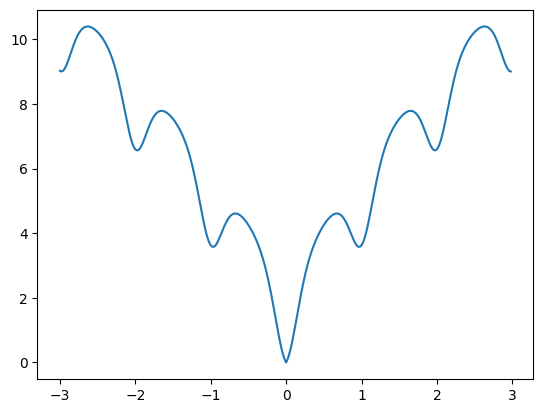

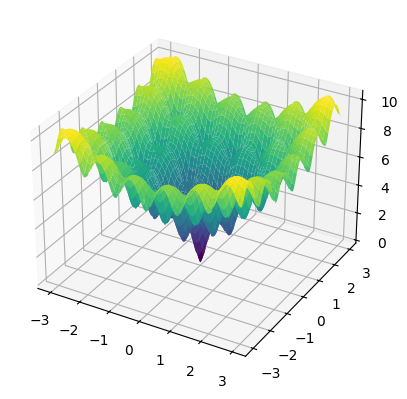

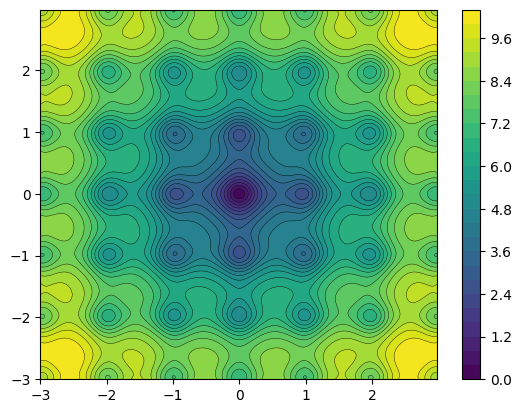

In [799]:
from matplotlib import pyplot as plt
import warnings

graphing_abs_bound = 2.5
graphing_abs_margin = .5

graphing_abs_frame = graphing_abs_bound + graphing_abs_margin

warnings.filterwarnings("ignore")
inputs_1d = np.arange(-graphing_abs_frame, graphing_abs_frame, 0.02, dtype=np.float64)

x_2d, y_2d = np.meshgrid(inputs_1d, inputs_1d)
inputs_2d = np.stack([x_2d.ravel(), y_2d.ravel()], axis=1)

outputs_1d = ackley_one_dim_vectorized(inputs_1d)
outputs_2d = np.apply_along_axis(ackley_two_dim, 1, inputs_2d)
z_2d = outputs_2d.reshape(x_2d.shape)

fig_1d, ax_1d = plt.subplots()
ax_1d.plot(inputs_1d, outputs_1d)

fig_2d_projection = plt.figure()
ax = fig_2d_projection.add_subplot(projection="3d")
ax.plot_surface(x_2d, y_2d, z_2d, cmap="viridis")
plt.show()

fig_2d_colours, ax_2d_colours = plt.subplots()
contour = ax_2d_colours.contourf(x_2d, y_2d, z_2d, levels=30, cmap="viridis")
ax_2d_colours.contour(x_2d, y_2d, z_2d, levels=30, colors="black", linewidths=0.3)
fig_2d_colours.colorbar(contour, ax=ax_2d_colours)
fig_2d_colours.show()

Now lets implement the basic Gradient Descent algorithm

In [800]:
def gradient_descent(
    start_pos: npt.NDArray[np.float64],
    step: float,
    iteration_amount: int,
    gradient_function: Callable[[npt.NDArray[np.float64]], npt.NDArray[np.float64]]
    ) -> npt.NDArray[np.float64]:
    pos = start_pos
    for _ in range(iteration_amount):
        pos = pos - step * gradient_function(pos)
    return pos

Lets see if the gradient descent function is able to find the local minimum and therefore, make the y smaller.
We will test both 1D and 2D versions of the Ackley function

In [801]:
from IPython.display import display
beta_1d = 0.001
iterations_1d = 100_000
start_pos_1d = np.array([2.123], dtype=np.float64)

beta_2d = 0.005
iterations_2d = 2_000
start_pos_2d = np.array([1.52, -0.94], dtype=np.float64)

after_descent_1d = gradient_descent(start_pos_1d, beta_1d, iterations_1d, ackley_one_dim_grad)
after_descent_2d = gradient_descent(start_pos_2d, beta_2d, iterations_2d, ackley_two_dim_grad)

y_start_1d = ackley_one_dim(start_pos_1d)
y_end_1d = ackley_one_dim(after_descent_1d)
y_start_2d = ackley_two_dim(start_pos_2d)
y_end_2d = ackley_two_dim(after_descent_2d)

print(f"""\
1D Ackley Function:
startPos: {start_pos_1d}
startY: {y_start_1d}

endPos: {after_descent_1d}
endY: {y_end_1d}


==========================


2D Ackley Function:
startPos: {start_pos_2d}
startY: {y_start_2d}

endPos: {after_descent_2d}
endY: {y_end_2d}
""")



1D Ackley Function:
startPos: [2.123]
startY: 7.5915529963737765

endPos: [1.97445199]
endY: 6.559645375627877




2D Ackley Function:
startPos: [ 1.52 -0.94]
startY: 6.215650983413973

endPos: [ 0.97980748 -0.97980748]
endY: 3.5808832550852583



We may visualize them using graphs. Any arrows pointing outside the view will be removed for clarity.

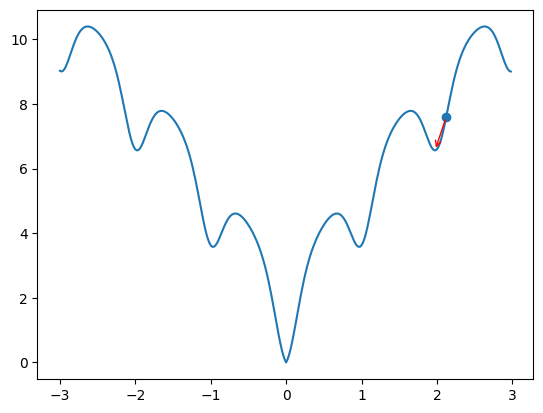

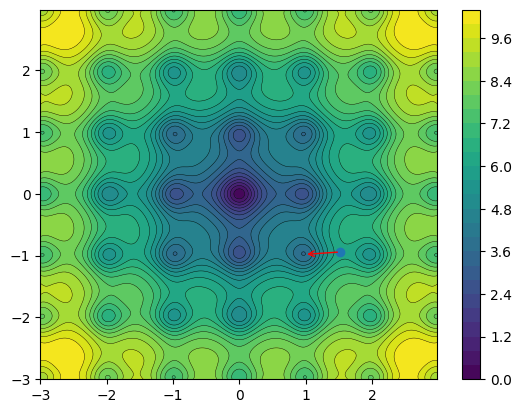

In [802]:
import copy

fig_1d_arrow = copy.deepcopy(fig_1d)
fig_2d_colours_arrow = copy.deepcopy(fig_2d_colours)

ax_1d_arrow = fig_1d_arrow.axes[0]
ax_2d_colours_arrow = fig_2d_colours_arrow.axes[0]

x_start_1d = start_pos_1d[0].item()

ax_1d_arrow.annotate(
    "",
    xy=(after_descent_1d[0].item(), y_end_1d),
    xytext=(x_start_1d, y_start_1d),
    arrowprops=dict(arrowstyle="->", color='r')
)
ax_1d_arrow.scatter([x_start_1d], [y_start_1d])
display(fig_1d_arrow)

start_pos_2d_tup = tuple(start_pos_2d)

ax_2d_colours_arrow.annotate(
    "",
    xy=(after_descent_2d[0].item(), after_descent_2d[1].item()),
    xytext=start_pos_2d_tup,
    arrowprops=dict(arrowstyle="->", color='r')
)
ax_2d_colours_arrow.scatter([start_pos_2d_tup[0]], [start_pos_2d_tup[1]])
display(fig_2d_colours_arrow)

Lets test a set of random starting points with 4 different beta values to test, how changing beta can impact the result

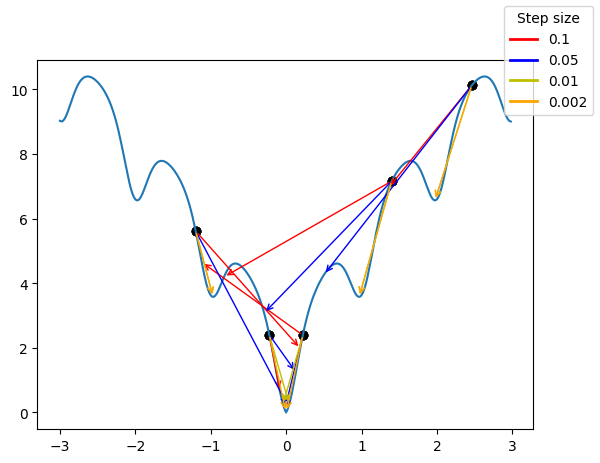

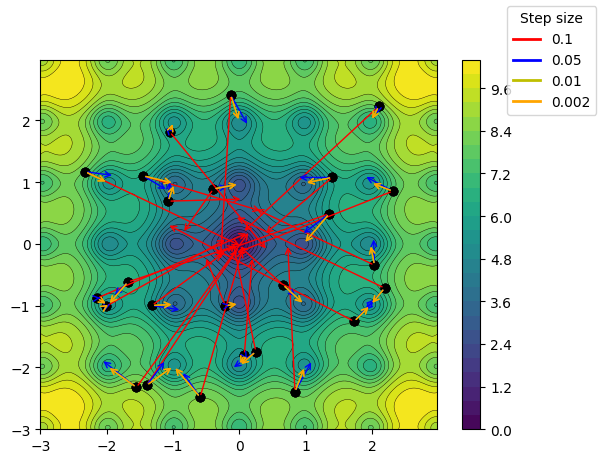

In [803]:
from typing import Any
from dataclasses import dataclass
from matplotlib.lines import Line2D
from matplotlib.axes import Axes
from matplotlib.figure import Figure

beta_multiple = np.array([0.1, 0.05, 0.01, 0.002], dtype=np.float64)
colours = ["r", "b", "y", "orange"]
iterations_multiple = 10_000
inputs_generated_1d = 5
inputs_generated_2d = 25

beta_colour_match = dict(zip(beta_multiple, colours))
# print(beta_colour_match)

fig_1d_arrow_multiple = copy.deepcopy(fig_1d)
fig_2d_colours_arrow_multiple = copy.deepcopy(fig_2d_colours)

ax_1d_arrow_multiple = fig_1d_arrow_multiple.axes[0]
ax_2d_colours_arrow_multiple = fig_2d_colours_arrow_multiple.axes[0]

inputs_1d_multiple = np.random.uniform(low=-graphing_abs_bound, high=graphing_abs_bound, size=(inputs_generated_1d,1))
inputs_2d_multiple = np.random.uniform(low=-graphing_abs_bound, high=graphing_abs_bound, size=(inputs_generated_2d,2))

inputs_1d_reshaped = np.reshape(inputs_1d_multiple, (inputs_generated_1d))
outputs_1d_multiple = ackley_one_dim_vectorized(inputs_1d_reshaped)


@dataclass
class Arrow:
    start_x: np.float64
    start_y: np.float64
    end_x: np.float64
    end_y: np.float64
    metadata: dict[str, Any]


arrow_list_1d_multiple: list[Arrow] = []
arrow_list_2d_multiple: list[Arrow] = []
for beta in beta_multiple:
    for inp, outp in zip(inputs_1d_multiple, outputs_1d_multiple):
        after_descent_1d_single = gradient_descent(inp, beta, iterations_multiple, ackley_one_dim_grad)
        arrow_list_1d_multiple.append(Arrow(
            inp[0],
            outp,
            after_descent_1d_single[0],
            np.float64(ackley_one_dim(after_descent_1d_single[0])),
            {
                "colour": beta_colour_match[beta],
                "step" : beta
            }
        ))

    for inp in inputs_2d_multiple:
        after_descent_2d_single = gradient_descent(inp, beta, iterations_multiple, ackley_two_dim_grad)
        arrow_list_2d_multiple.append(Arrow(
            inp[0],
            inp[1],
            after_descent_2d_single[0],
            after_descent_2d_single[1],
            {
                "colour": beta_colour_match[beta],
                "step" : beta
            }
        ))

# print(after_descent_1d_multiple)

def annotate_arrows(arrow_list: list[Arrow], axis: Axes) -> None:
    for arrow in arrow_list:
        axis.annotate(
            "",
            xy=(arrow.end_x, arrow.end_y),
            xytext=(arrow.start_x, arrow.start_y),
            arrowprops=dict(arrowstyle="->", color=arrow.metadata["colour"])
        )

def seperate_starting_points(arrow_list: list[Arrow]) -> tuple[np.float64, np.float64]:
    points = np.array([(elem.start_x, elem.start_y) for elem in arrow_list])
    transposed = points.T
    return transposed[0], transposed[1]

def plot_gradient_descent(arrows: list[Arrow], ax: Axes, fig: Figure):
    annotate_arrows(arrows, ax)
    # print(arrows)
    sp = seperate_starting_points(arrows)
    # print(sp)
    ax.scatter(*sp, c="black")
    legend_elements = [
        Line2D([0], [0], color=color, lw=2, label=beta)
        for beta, color in beta_colour_match.items()
    ]
    fig.legend(handles=legend_elements, title="Step size")
    display(fig)

plot_gradient_descent(arrow_list_1d_multiple, ax_1d_arrow_multiple, fig_1d_arrow_multiple)
plot_gradient_descent(arrow_list_2d_multiple, ax_2d_colours_arrow_multiple, fig_2d_colours_arrow_multiple)


Lets define the Gradient Descent With Momentum function and check if it generates more accurate outputs

In [804]:
def gradient_descent_with_momentum(
    start_pos: npt.NDArray[np.float64],
    step: float,
    momentum_coefficient: float,
    iteration_amount: int,
    gradient_function: Callable[[npt.NDArray[np.float64]], npt.NDArray[np.float64]]
    ) -> npt.NDArray[np.float64]:
    pos = start_pos.copy()
    v = np.zeros_like(start_pos)
    for _ in range(iteration_amount):
        v = momentum_coefficient * v + step * gradient_function(pos)
        pos = pos - v
    return pos

Now the first check if our GDWM can find a point that yields smaller output when used as the Ackley function's argument

In [805]:
from IPython.display import display

step = 0.01
momentum_coefficient = 0.9
iterations = 100_000
start_pos_1d = np.array([2.123], dtype=np.float64)
start_pos_2d = np.array([1.52, -0.94], dtype=np.float64)

after_descent_1d = gradient_descent_with_momentum(start_pos_1d, step, momentum_coefficient, iterations, ackley_one_dim_grad)
after_descent_2d = gradient_descent_with_momentum(start_pos_2d, step, momentum_coefficient, iterations, ackley_two_dim_grad)

y_start_1d = ackley_one_dim(start_pos_1d)
y_end_1d = ackley_one_dim(after_descent_1d)

y_start_2d = ackley_two_dim(start_pos_2d)
y_end_2d = ackley_two_dim(after_descent_2d)

print(f"""\
1D Ackley Function:
startPos: {start_pos_1d}
startY: {y_start_1d}

endPos: {after_descent_1d}
endY: {y_end_1d}


==========================


2D Ackley Function:
startPos: {start_pos_2d}
startY: {y_start_2d}

endPos: {after_descent_2d}
endY: {y_end_2d}
""")



1D Ackley Function:
startPos: [2.123]
startY: 7.5915529963737765

endPos: [1.97445199]
endY: 6.559645375627877




2D Ackley Function:
startPos: [ 1.52 -0.94]
startY: 6.215650983413973

endPos: [ 0.97980748 -0.97980748]
endY: 3.5808832550852583



Now we may graph them, with multiple different step values and, similarly to the basic GD, comparing the outputs for the same inputs to check if it performed better

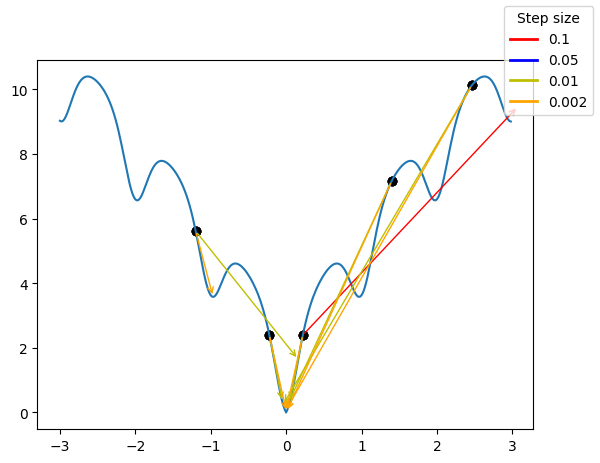

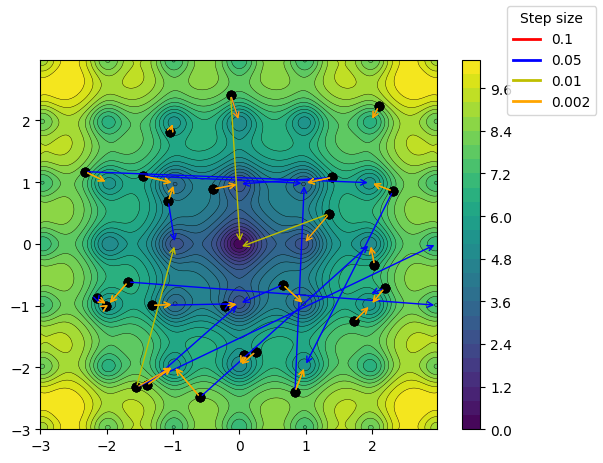

In [806]:
momentum_coefficient_multiple = 0.9

fig_1d_arrow_multiple_momentum = copy.deepcopy(fig_1d)
fig_2d_colours_arrow_multiple_momentum = copy.deepcopy(fig_2d_colours)

ax_1d_arrow_multiple_momentum = fig_1d_arrow_multiple_momentum.axes[0]
ax_2d_colours_arrow_multiple_momentum = fig_2d_colours_arrow_multiple_momentum.axes[0]

arrow_list_1d_multiple_momentum: list[Arrow] = []
arrow_list_2d_multiple_momentum: list[Arrow] = []
for beta in beta_multiple:
    for inp, outp in zip(inputs_1d_multiple, outputs_1d_multiple):
        after_descent_1d_single = gradient_descent_with_momentum(inp, beta, momentum_coefficient_multiple, iterations_multiple, ackley_one_dim_grad)
        # print(f"({inp[0]}, {outp}) -> ({after_descent_1d_single[0]}, {np.float64(ackley_one_dim(after_descent_1d_single[0]))}) @ {beta}")
        arrow_list_1d_multiple_momentum.append(Arrow(
            inp[0],
            outp,
            after_descent_1d_single[0],
            np.float64(ackley_one_dim(after_descent_1d_single[0])),
            {
                "colour": beta_colour_match[beta],
                "step" : beta
            }
        ))

    for inp in inputs_2d_multiple:
        after_descent_2d_single = gradient_descent_with_momentum(inp, beta, momentum_coefficient_multiple, iterations_multiple, ackley_two_dim_grad)
        arrow_list_2d_multiple_momentum.append(Arrow(
            inp[0],
            inp[1],
            after_descent_2d_single[0],
            after_descent_2d_single[1],
            {
                "colour": beta_colour_match[beta],
                "step" : beta
            }
        ))

plot_gradient_descent(arrow_list_1d_multiple_momentum, ax_1d_arrow_multiple_momentum, fig_1d_arrow_multiple_momentum)
plot_gradient_descent(arrow_list_2d_multiple_momentum, ax_2d_colours_arrow_multiple_momentum, fig_2d_colours_arrow_multiple_momentum)

Finally, we can compare Gradient Descent to Gradient Descent With Momentum. For the comparison we will use step = 0.01 as both approaches performed well with this coefficient.

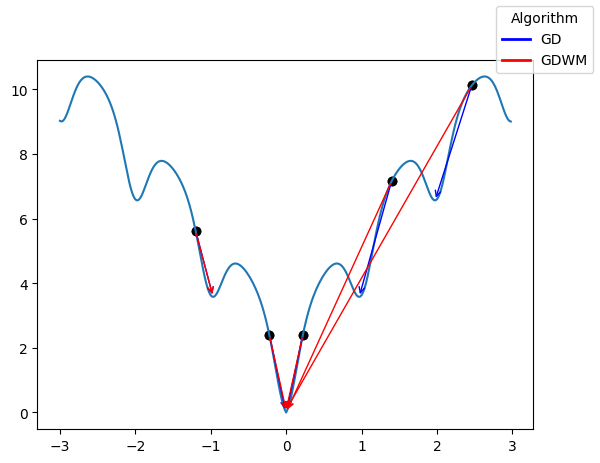

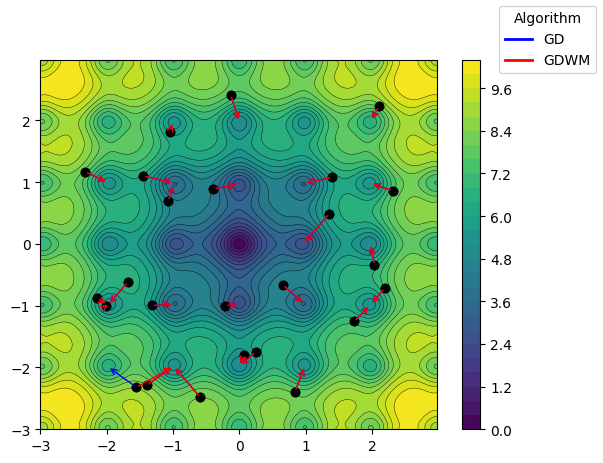

In [807]:
momentum_colour = "red"
regular_colour = "blue"

fig_1d_arrow_multiple_comparison = copy.deepcopy(fig_1d)
fig_2d_colours_arrow_multiple_comparison = copy.deepcopy(fig_2d_colours)

ax_1d_arrow_multiple_comparison = fig_1d_arrow_multiple_comparison.axes[0]
ax_2d_colours_arrow_multiple_comparison = fig_2d_colours_arrow_multiple_comparison.axes[0]

def has_smallest_step(arrow: Arrow) -> bool:
    return arrow.metadata["step"] == min(beta_multiple)

def change_arrow_colour(arrow: Arrow, colour: str) -> Arrow:
    arrow.metadata["colour"] = colour
    return arrow

def filter_smallest_beta(arrow_list: list[Arrow]) -> list[Arrow]:
    return list(filter(has_smallest_step, arrow_list))

arrow_list_1d_multiple_comparison = filter_smallest_beta(arrow_list_1d_multiple)
arrow_list_1d_multiple_momentum_comparison = filter_smallest_beta(arrow_list_1d_multiple_momentum)
arrow_list_2d_multiple_comparison = filter_smallest_beta(arrow_list_2d_multiple)
arrow_list_2d_multiple_momentum_comparison = filter_smallest_beta(arrow_list_2d_multiple_momentum)

arrow_list_1d_multiple_comparison = list(map(lambda x: change_arrow_colour(x, regular_colour), arrow_list_1d_multiple_comparison))
arrow_list_1d_multiple_momentum_comparison = list(map(lambda x: change_arrow_colour(x, momentum_colour), arrow_list_1d_multiple_momentum_comparison))
arrow_list_2d_multiple_comparison = list(map(lambda x: change_arrow_colour(x, regular_colour), arrow_list_2d_multiple_comparison))
arrow_list_2d_multiple_momentum_comparison = list(map(lambda x: change_arrow_colour(x, momentum_colour), arrow_list_2d_multiple_momentum_comparison))

# print(arrow_list_1d_multiple_comparison)
# print(arrow_list_1d_multiple_momentum_comparison)
# print(arrow_list_2d_multiple_comparison)
# print(arrow_list_2d_multiple_momentum_comparison)

annotate_arrows(arrow_list_1d_multiple_comparison, ax_1d_arrow_multiple_comparison)
annotate_arrows(arrow_list_1d_multiple_momentum_comparison, ax_1d_arrow_multiple_comparison)
sp = seperate_starting_points(arrow_list_1d_multiple_comparison)
ax_1d_arrow_multiple_comparison.scatter(*sp, c="black")
sp = seperate_starting_points(arrow_list_1d_multiple_momentum_comparison)
ax_1d_arrow_multiple_comparison.scatter(*sp, c="black")

legend_elements = [
    Line2D([0], [0], color=regular_colour, lw=2, label="GD"),
    Line2D([0], [0], color=momentum_colour, lw=2, label="GDWM"),
]
fig_1d_arrow_multiple_comparison.legend(handles=legend_elements, title="Algorithm")
display(fig_1d_arrow_multiple_comparison)

annotate_arrows(arrow_list_2d_multiple_comparison, ax_2d_colours_arrow_multiple_comparison)
annotate_arrows(arrow_list_2d_multiple_momentum_comparison, ax_2d_colours_arrow_multiple_comparison)
sp = seperate_starting_points(arrow_list_2d_multiple_comparison)
ax_2d_colours_arrow_multiple_comparison.scatter(*sp, c="black")
sp = seperate_starting_points(arrow_list_2d_multiple_momentum_comparison)
ax_2d_colours_arrow_multiple_comparison.scatter(*sp, c="black")

fig_2d_colours_arrow_multiple_comparison.legend(handles=legend_elements, title="Algorithm")
display(fig_2d_colours_arrow_multiple_comparison)


As we can observe, there are cases, where Gradient Descent With Momentum does go towards the global maximum even despite starting far away from it. On the other hand, regular Gradient Descent tends to go towards the closest local minimum in almost all cases. This advantage seems to be much more prominent in 1D version (most of GDWMs go to the desired point) than in 2D (basically the same for both algorithms). Gradient Descent With Momentum can be considered superior in our case, as, on average, it provides more optimal results.